Import Libraries

In [1]:
from qiskit.qasm2 import load
from qiskit_aer import AerSimulator

Load the OpenQASM file

In [2]:
circuit = load("article-12-bell.qasm")
print("Circuit successfully loaded!")
circuit.draw()

Circuit successfully loaded!


┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

Run the circuit on AerSimulator

In [3]:
simulator = AerSimulator()
job = simulator.run(circuit, shots=1024)
counts = job.result().get_counts()
print("Measurement results:", counts)

Measurement results: {'11': 517, '00': 507}


Visualize the results

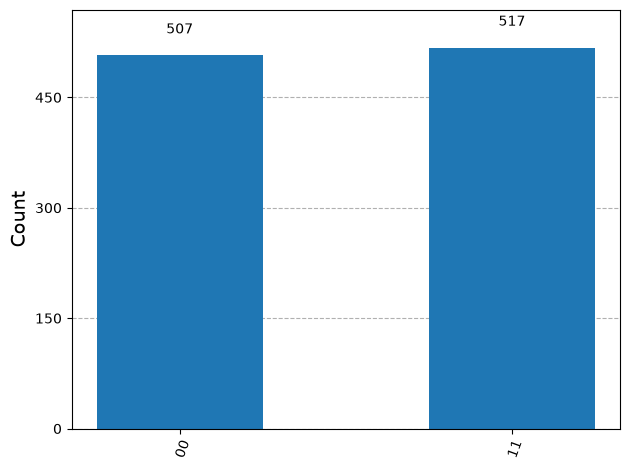

In [4]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

Build and export

In [5]:
from qiskit import QuantumCircuit, qasm2

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

# Export to OpenQASM 2 string
qasm_string = qasm2.dumps(qc)
print(qasm_string)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


Complete Notebook Code

In [6]:
from qiskit import QuantumCircuit, qasm2
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

with open("article-12-new-bell.qasm", "w") as f:
    f.write(qasm2.dumps(qc))

circuit = qasm2.load("article-12-new-bell.qasm")
print("Circuit successfully loaded!")
print(circuit.draw())

simulator = AerSimulator()
job = simulator.run(circuit, shots=1024)
counts = job.result().get_counts()
print("Measurement results:", counts)

plot_histogram(counts)

print("\nGenerated QASM String:")
print(qasm2.dumps(qc))

Circuit successfully loaded!
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
Measurement results: {'00': 538, '11': 486}

Generated QASM String:
OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];
